Importing the Dependencies

In [1]:
# Importing required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

Data Collection and Analysis

In [2]:
# loading the data from csv file to a pandas data frae
customer_data = pd.read_csv("/content/Mall_Customers.csv")

In [3]:
# first 5 rows in a data frame
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# finding the number of rows and columns
customer_data.shape

(200, 5)

In [5]:
# getting some information about the dataset
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# Statistical summary

customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
# checking for missing values
customer_data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
# Checking for duplicate rows

print("Duplicate rows:", customer_data.duplicated().sum())

# If there are duplicates drop it
customer_data = customer_data.drop_duplicates()

Duplicate rows: 0


Exploratory Data Analysis

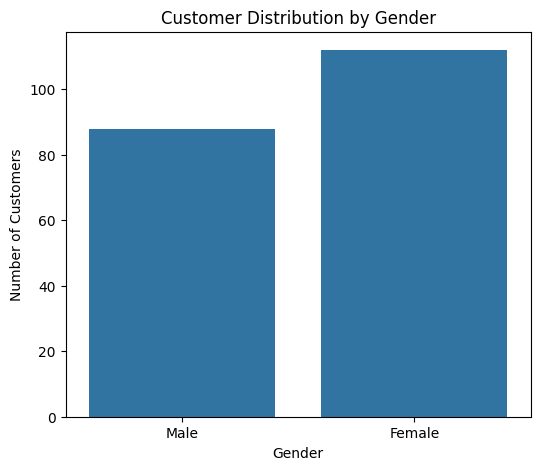

In [8]:
# Gender Distribution

plt.figure(figsize=(6, 5))

sns.countplot(data=customer_data, x='Gender')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

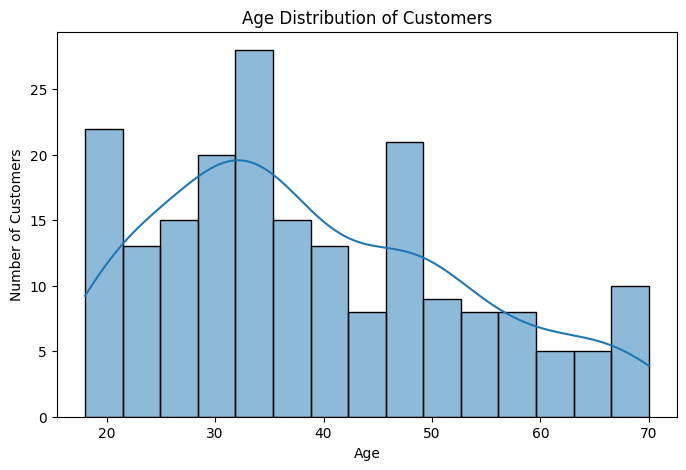

In [9]:
# Age Distribution
plt.figure(figsize=(8, 5))

sns.histplot(customer_data['Age'], bins=15, kde=True)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

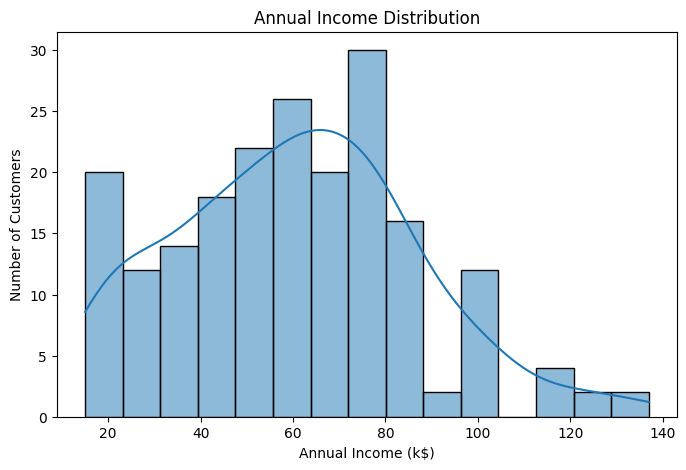

In [10]:
# Annual Income Distribution

plt.figure(figsize=(8, 5))

sns.histplot(customer_data['Annual Income (k$)'], bins=15, kde=True)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')

plt.show()

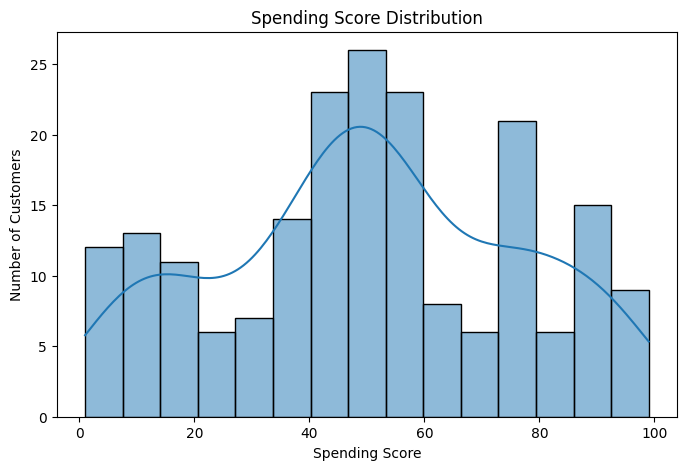

In [11]:
# Spending Score Distribution

plt.figure(figsize=(8, 5))

sns.histplot(customer_data['Spending Score (1-100)'], bins=15, kde=True)

plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')

plt.show()

Correlation Analysis

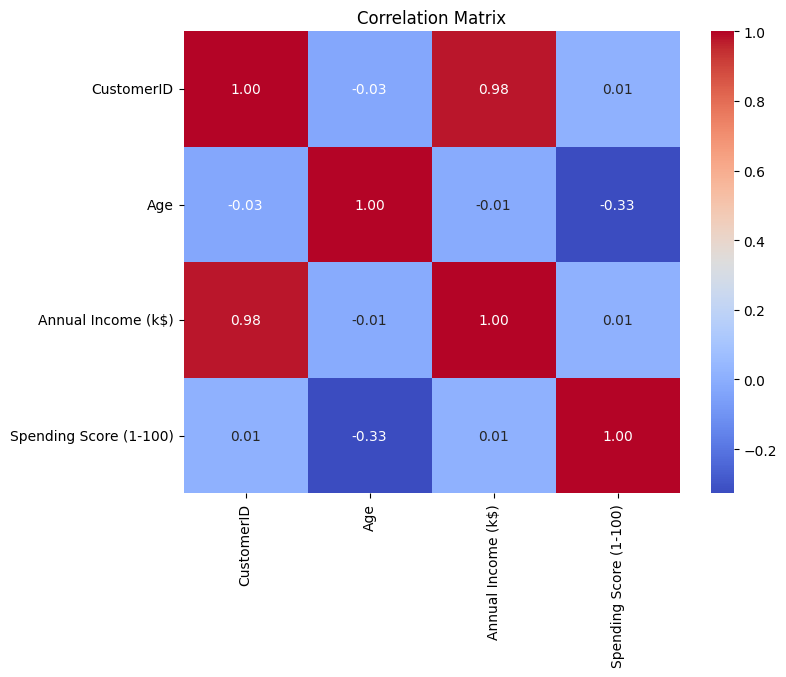

In [12]:
plt.figure(figsize=(8, 6))

numeric_data = customer_data.select_dtypes(include=np.number)

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

Choosing the Annual Income Column & Spending Score Column

In [13]:
# Selecting features for clustering
X = customer_data[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [14]:
print(X[:5])

[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


Standardize the Data

In [15]:
# Standardizing the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


Choosing Number of Clusters

WCSS -> Within Clusters Sum of Squares

In [16]:
# finding WCSS value for different number of cluster

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

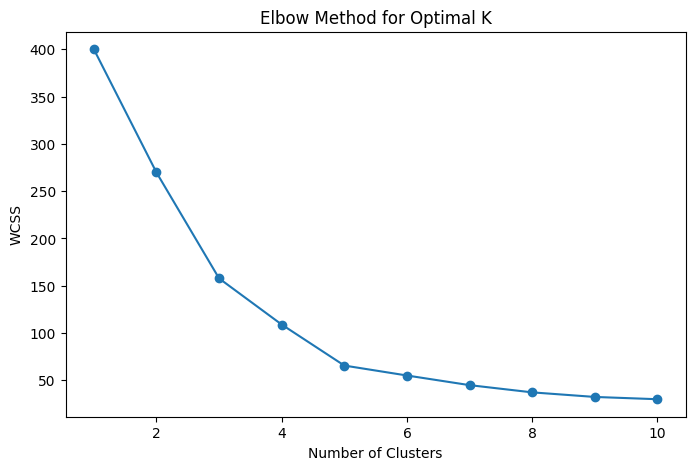

In [17]:
# plot an elbow graph

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

Silhouette Score

In [18]:
# Calculating Silhouette Scores

silhouette_scores = []

for i in range(2, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"K = {i}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.321
K = 3, Silhouette Score = 0.467
K = 4, Silhouette Score = 0.494
K = 5, Silhouette Score = 0.555
K = 6, Silhouette Score = 0.540
K = 7, Silhouette Score = 0.528
K = 8, Silhouette Score = 0.455
K = 9, Silhouette Score = 0.457
K = 10, Silhouette Score = 0.443


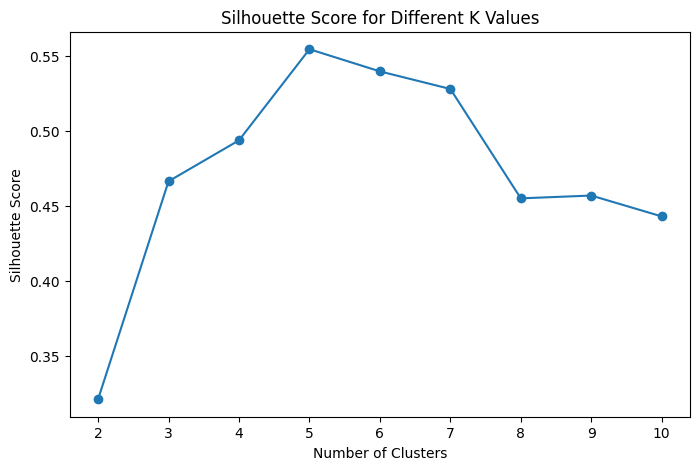

In [19]:
# plot

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.show()

Optimum Number of Clusters = 5

```
I evaluated multiple values of K using both the Elbow Method and Silhouette Score and selected K=5 based on cluster compactness and separation
```



Training the k-means Clustering Model

In [20]:
# Training the final K-Means model

optimal_clusters = 5

kmeans = KMeans(
    n_clusters=optimal_clusters,
    init='k-means++',
    n_init=10,
    random_state=42
)

Y = kmeans.fit_predict(X_scaled)

print(Y)


[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [21]:
# Adding cluster labels to the original dataset

customer_data['Cluster'] = Y

customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Create Cluster Profile

In [22]:
# Creating a customer profile for each cluster

cluster_profile = customer_data.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending=('Spending Score (1-100)', 'mean')
).round(2)

cluster_profile

,Customers,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [23]:
# Percentage of Customers

cluster_profile['Customer_Percentage'] = (
    cluster_profile['Customers']
    / len(customer_data)
    * 100
).round(2)

cluster_profile

,Customers,Average_Age,Average_Income,Average_Spending,Customer_Percentage
Cluster,,,,,
0,81,42.72,55.30,49.52,40.5
1,39,32.69,86.54,82.13,19.5
2,22,25.27,25.73,79.36,11.0
3,35,41.11,88.20,17.11,17.5
4,23,45.22,26.30,20.91,11.5


Identify the Cluster Characteristics

In [24]:
# Convert standardized centroids back to original units

centroids_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroid_data = pd.DataFrame(
    centroids_original,
    columns=[
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
)

centroid_data.index.name = 'Cluster'

centroid_data.round(2)

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91


In [25]:
# Giving meaningful business names to the clusters

cluster_names = {
    0: 'Potential Customers',
    1: 'High-Value Customers',
    2: 'Standard Customers',
    3: 'Low-Value Customers',
    4: 'High-Income Low-Spending Customers'
}

customer_data['Customer Segment'] = customer_data['Cluster'].map(cluster_names)

customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,4,High-Income Low-Spending Customers
1,2,Male,21,15,81,2,Standard Customers
2,3,Female,20,16,6,4,High-Income Low-Spending Customers
3,4,Female,23,16,77,2,Standard Customers
4,5,Female,31,17,40,4,High-Income Low-Spending Customers


Visualizing all the Clusters


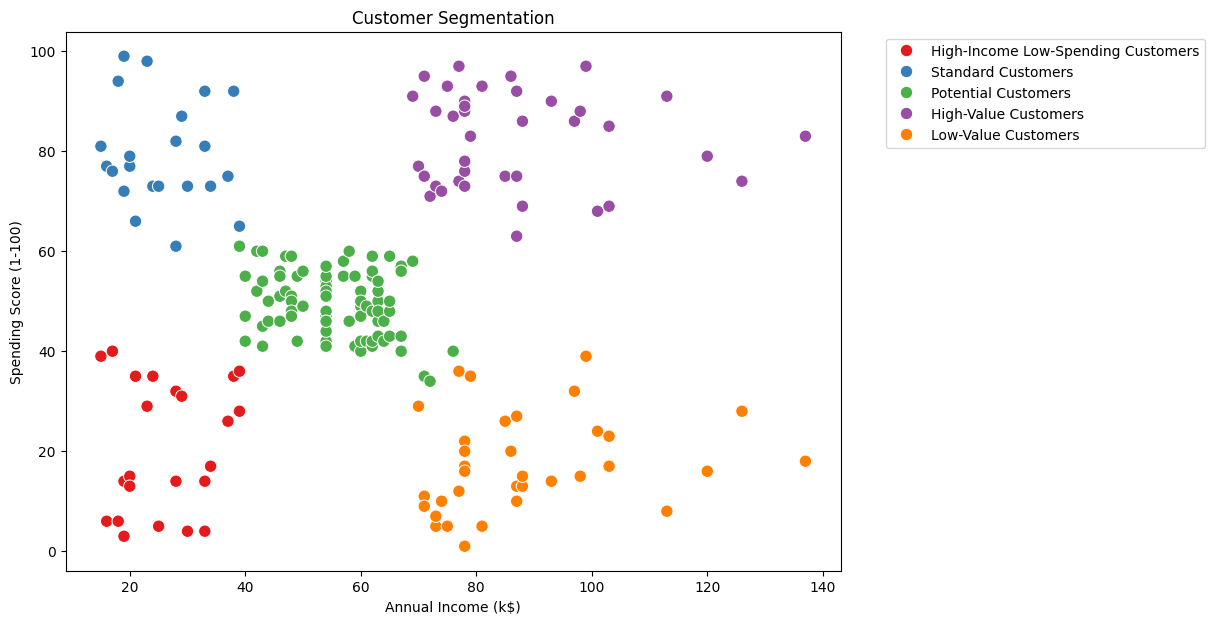

In [26]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=customer_data,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Customer Segment',
    palette='Set1',
    s=80
)

plt.title('Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

Plot the Centroids

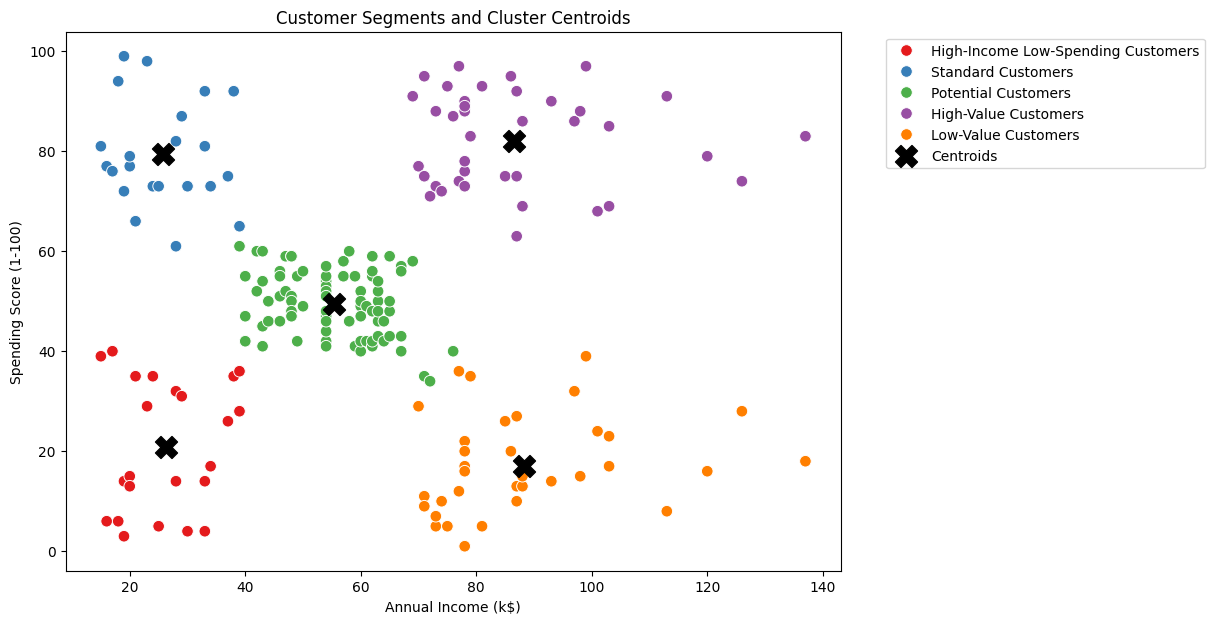

In [27]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=customer_data,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Customer Segment',
    palette='Set1',
    s=70
)

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    s=250,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments and Cluster Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

Compare Segment Sizes

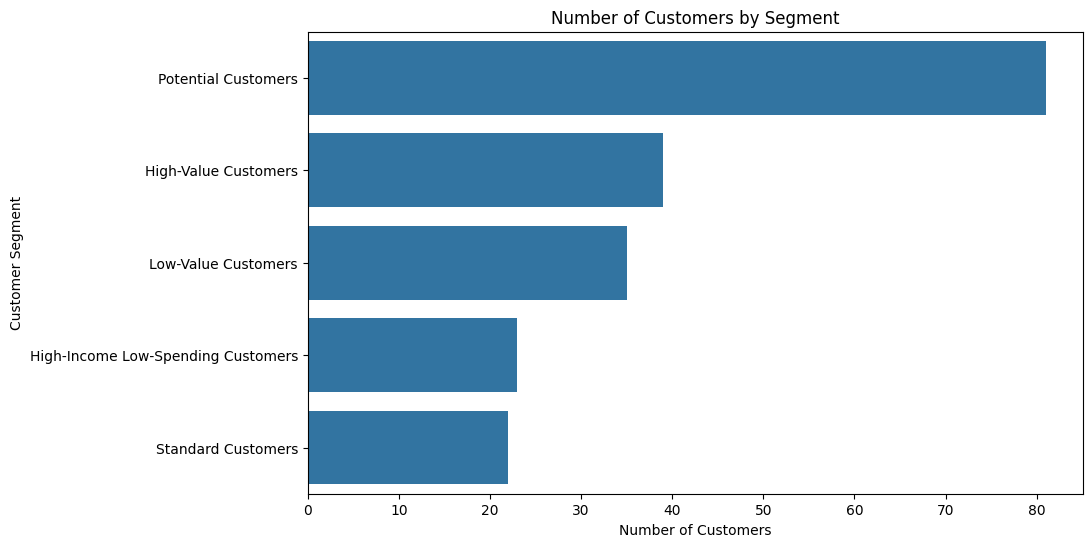

In [28]:
plt.figure(figsize=(10, 6))

segment_counts = customer_data['Customer Segment'].value_counts()

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.title('Number of Customers by Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')

plt.show()

Analyze Gender by Customer Segment

In [29]:
gender_segment = pd.crosstab(
    customer_data['Customer Segment'],
    customer_data['Gender']
)

gender_segment

Gender,Female,Male
Customer Segment,,
High-Income Low-Spending Customers,14,9
High-Value Customers,21,18
Low-Value Customers,16,19
Potential Customers,48,33
Standard Customers,13,9


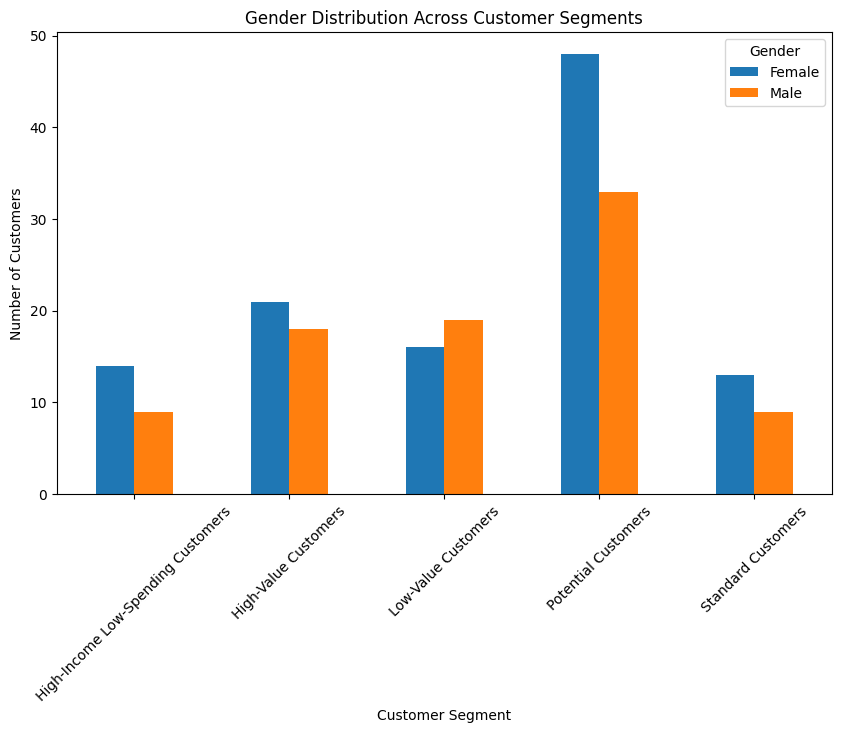

In [30]:
# visualising

gender_segment.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Gender Distribution Across Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.legend(title='Gender')

plt.show()

Analyze age by segment

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=customer_data,
    x='Customer Segment',
    y='Age'
)

plt.title('Age Distribution Across Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Age')

plt.xticks(rotation=45)

plt.show()

Business Recommendation Table

In [32]:
recommendations = {
    'High-Value Customers':
        'Offer VIP rewards, loyalty benefits and premium products.',

    'Potential Customers':
        'Use personalized promotions and targeted discounts to increase retention.',

    'Standard Customers':
        'Use regular promotions, cross-selling and loyalty campaigns.',

    'Low-Value Customers':
        'Use low-cost promotional campaigns and monitor engagement.',

    'High-Income Low-Spending Customers':
        'Use personalized recommendations and premium offers to increase spending.'
}

In [33]:
cluster_profile['Customer Segment'] = [
    cluster_names[i]
    for i in cluster_profile.index
]

cluster_profile['Recommended Strategy'] = (
    cluster_profile['Customer Segment']
    .map(recommendations)
)

cluster_profile

,Customers,Average_Age,Average_Income,Average_Spending,Customer_Percentage,Customer Segment,Recommended Strategy
Cluster,,,,,,,
0,81,42.72,55.30,49.52,40.5,Potential Customers,Use personalized promotions and targeted disco...
1,39,32.69,86.54,82.13,19.5,High-Value Customers,"Offer VIP rewards, loyalty benefits and premiu..."
2,22,25.27,25.73,79.36,11.0,Standard Customers,"Use regular promotions, cross-selling and loya..."
3,35,41.11,88.20,17.11,17.5,Low-Value Customers,Use low-cost promotional campaigns and monitor...
4,23,45.22,26.30,20.91,11.5,High-Income Low-Spending Customers,Use personalized recommendations and premium o...


Generate Usefull Business Insight

In [34]:
# calculate biggest customer segment

largest_segment = (
    customer_data['Customer Segment']
    .value_counts()
    .idxmax()
)

largest_segment_count = (
    customer_data['Customer Segment']
    .value_counts()
    .max()
)

print(
    f"The largest customer segment is '{largest_segment}' "
    f"with {largest_segment_count} customers."
)

The largest customer segment is 'Potential Customers' with 81 customers.


In [35]:
# Calculate highest spending segment

highest_spending_segment = (
    cluster_profile.loc[
        cluster_profile['Average_Spending'].idxmax(),
        'Customer Segment'
    ]
)

print(
    f"The highest-spending customer segment is "
    f"'{highest_spending_segment}'."
)

The highest-spending customer segment is 'High-Value Customers'.


In [36]:
# Calculate Highest Income Segment

highest_income_segment = (
    cluster_profile.loc[
        cluster_profile['Average_Income'].idxmax(),
        'Customer Segment'
    ]
)

print(
    f"The highest-income customer segment is "
    f"'{highest_income_segment}'."
)

The highest-income customer segment is 'Low-Value Customers'.


In [37]:
# Exporting the segmented customer dataset

customer_data.to_csv(
    "/content/customer_segmented.csv",
    index=False
)

print("File exported successfully!")

File exported successfully!
